#**Environment setup**

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

#**Fix random seed**

In [2]:

SEED = 42

def set_global_seed(seed_value):
    os.environ["PYTHONHASHSEED"] = str(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)

set_global_seed(SEED)

#**Project configuration and Paths**

In [3]:

config = {
    "seed": 42,
    "img_size": (224, 224),
    "img_shape": (224, 224, 3),
    "batch_size": 32,
    "epochs": 30,
    "learning_rate": 1e-3,
    "classes": ["NORMAL", "PNEUMONIA"],
}

SEED = config["seed"]
IMG_SIZE = config["img_size"]
IMG_SHAPE = config["img_shape"]
BATCH_SIZE = config["batch_size"]
EPOCHS = config["epochs"]
LR = config["learning_rate"]
CLASS_NAMES = config["classes"]

#Folder locations
DRIVE_DATASET_DIR = "/content/drive/MyDrive/Dataset/Archive_dataset"
LOCAL_DATASET_DIR = "/Dataset/Archive_dataset"

BASE_DIR = LOCAL_DATASET_DIR
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")
TEST_DIR = os.path.join(BASE_DIR, "test")

In [5]:
import shutil

if os.path.exists(LOCAL_DATASET_DIR):
    print(f"Local dataset folder already exists: {LOCAL_DATASET_DIR}")
else:
    print("Copying dataset from Google Drive to local storage...")
    shutil.copytree(DRIVE_DATASET_DIR, LOCAL_DATASET_DIR)
    print("Dataset copied successfully.")

expected_splits = ["train", "val", "test"]
expected_classes = CLASS_NAMES

for split in expected_splits:
    split_dir = os.path.join(BASE_DIR, split)
    print(f"\nChecking: {split_dir}")

    if not os.path.exists(split_dir):
        print(f"  Missing split folder: {split}")
        continue

    for class_name in expected_classes:
        class_dir = os.path.join(split_dir, class_name)
        if os.path.exists(class_dir):
            num_images = len([
                f for f in os.listdir(class_dir)
                if os.path.isfile(os.path.join(class_dir, f))
            ])
            print(f"  {split}/{class_name}: {num_images} images")
        else:
            print(f"  Missing class folder: {split}/{class_name}")

Local dataset folder already exists: /Dataset/Archive_dataset

Checking: /Dataset/Archive_dataset/train
  train/NORMAL: 1341 images
  train/PNEUMONIA: 3875 images

Checking: /Dataset/Archive_dataset/val
  val/NORMAL: 8 images
  val/PNEUMONIA: 8 images

Checking: /Dataset/Archive_dataset/test
  test/NORMAL: 234 images
  test/PNEUMONIA: 390 images


#**Data augmentation and Preprocessing**

In [6]:

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=12,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.08,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(rescale=1.0/255)
test_datagen = ImageDataGenerator(rescale=1.0/255)

#**Load images from directories**

In [7]:

train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=CLASS_NAMES,
    shuffle=True,
    seed=SEED
)

val_data = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=CLASS_NAMES,
    shuffle=False
)

test_data = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    classes=CLASS_NAMES,
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


#**Check dataset shape**

In [8]:


print("Dataset Summary")
print("-" * 40)
print(f"Training samples   : {train_data.samples}")
print(f"Validation samples : {val_data.samples}")
print(f"Test samples       : {test_data.samples}")

print("\nClass mapping")
print("-" * 40)
print(train_data.class_indices)

x_batch, y_batch = next(train_data)

print("\nOne training batch")
print("-" * 40)
print(f"Images batch shape : {x_batch.shape}")
print(f"Labels batch shape : {y_batch.shape}")

Dataset Summary
----------------------------------------
Training samples   : 5216
Validation samples : 16
Test samples       : 624

Class mapping
----------------------------------------
{'NORMAL': 0, 'PNEUMONIA': 1}

One training batch
----------------------------------------
Images batch shape : (32, 224, 224, 3)
Labels batch shape : (32,)


#**Show sample X-ray images**

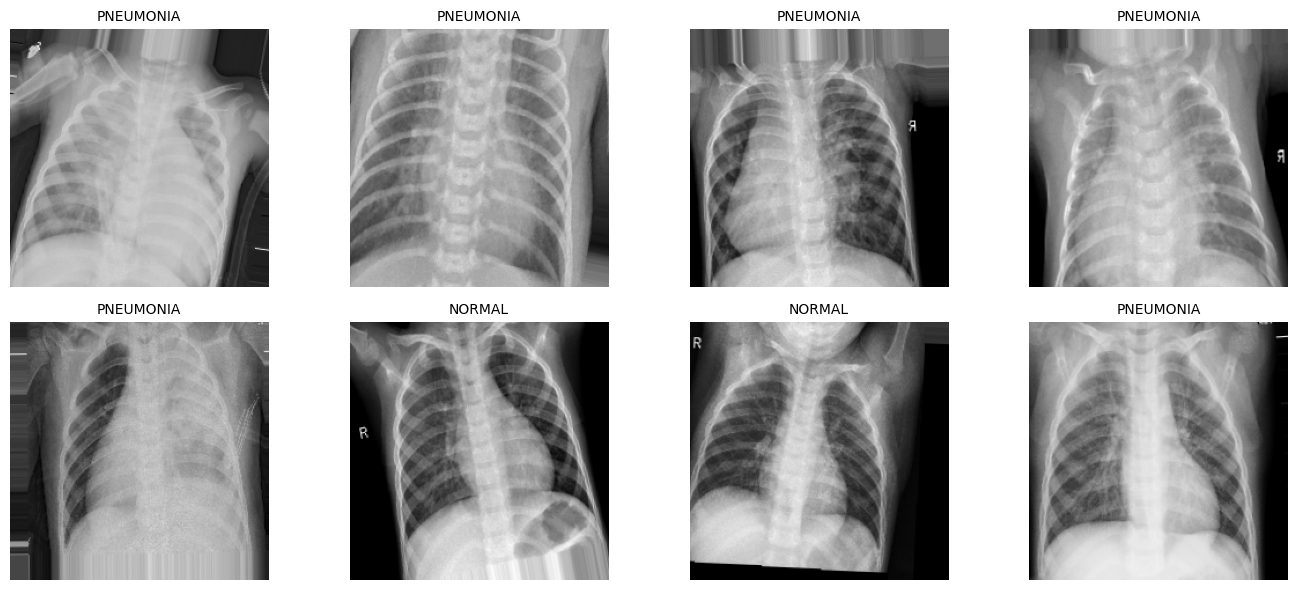

In [9]:


def visualize_samples(generator, class_names, n=8):
    images, labels = next(generator)
    n = min(n, images.shape[0])

    plt.figure(figsize=(14, 6))
    for i in range(n):
        plt.subplot(2, n // 2, i + 1)
        plt.imshow(images[i])
        label_idx = int(labels[i])
        plt.title(class_names[label_idx], fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

visualize_samples(train_data, CLASS_NAMES, n=8)

#**Balance class weights**

In [10]:


class_labels = np.unique(train_data.classes)
weights = compute_class_weight(
    class_weight="balanced",
    classes=class_labels,
    y=train_data.classes
)

class_weight_dict = dict(zip(class_labels, weights))

print("Class Weights")
print("-" * 40)
for class_name, class_idx in train_data.class_indices.items():
    print(f"{class_name} ({class_idx}): {class_weight_dict[class_idx]:.4f}")

Class Weights
----------------------------------------
NORMAL (0): 1.9448
PNEUMONIA (1): 0.6730


#**Inspect label counts**

In [11]:


def print_distribution(labels, class_indices, name):
    print(f"\n{name} Distribution")
    print("-" * 40)
    for class_name, class_idx in class_indices.items():
        count = np.sum(labels == class_idx)
        print(f"{class_name}: {count}")

print_distribution(val_data.classes, val_data.class_indices, "Validation")

print_distribution(test_data.classes, test_data.class_indices, "Test")


Validation Distribution
----------------------------------------
NORMAL: 8
PNEUMONIA: 8

Test Distribution
----------------------------------------
NORMAL: 234
PNEUMONIA: 390


#**Build the CNN model**

In [12]:


def add_conv_block(model, filters, dropout_rate):
    model.add(layers.Conv2D(filters, (3, 3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Conv2D(filters, (3, 3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(dropout_rate))


model = models.Sequential(name="custom_cnn")
model.add(layers.Input(shape=IMG_SHAPE))

for filters, dropout_rate in [(32, 0.25), (64, 0.30), (128, 0.40)]:
    add_conv_block(model, filters, dropout_rate)

model.add(layers.Flatten())
model.add(layers.Dense(256))
model.add(layers.BatchNormalization())
model.add(layers.ReLU())
model.add(layers.Dropout(0.50))
model.add(layers.Dense(1, activation="sigmoid"))

model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 56, 56, 128)    │             

 Total params: 25,980,449 (99.11 MB)

 Trainable params: 25,979,041 (99.10 MB)

 Non-trainable params: 1,408 (5.50 KB)

#**Compile the model**

In [13]:


opt = tf.keras.optimizers.Adam(learning_rate=LR)
recall_metric = tf.keras.metrics.Recall(name="recall")
auc_metric = tf.keras.metrics.AUC(name="auc")

model.compile(
    optimizer=opt,
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy", recall_metric, auc_metric]
)

print("Compilation done")
print(f"Optimizer : Adam (lr={LR})")
print("Loss      : BinaryCrossentropy")
print("Metrics   : accuracy, recall, auc")

Compilation done
Optimizer : Adam (lr=0.001)
Loss      : BinaryCrossentropy
Metrics   : accuracy, recall, auc


#**Set training callbacks**

In [14]:

save_dir = "/Dataset/saved_models"
os.makedirs(save_dir, exist_ok=True)


early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = callbacks.ModelCheckpoint(
    filepath=os.path.join(save_dir, "custom_cnn_best.keras"),
    monitor="val_loss",
    save_best_only=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

my_callbacks = [early_stop, checkpoint, reduce_lr]


print("Callbacks configured:")
print("- EarlyStopping (monitor=val_loss, patience=5, restore_best_weights=True)")
print("- ModelCheckpoint (save_best_only=True, path=/content/saved_models/custom_cnn_best.keras)")
print("- ReduceLROnPlateau (monitor=val_loss, factor=0.5, patience=3, min_lr=1e-7)")

Callbacks configured:
- EarlyStopping (monitor=val_loss, patience=5, restore_best_weights=True)
- ModelCheckpoint (save_best_only=True, path=/content/saved_models/custom_cnn_best.keras)
- ReduceLROnPlateau (monitor=val_loss, factor=0.5, patience=3, min_lr=1e-7)


#**Start model training**

In [15]:


print("Model training is running...")

train_log = model.fit(
    train_data,
    epochs=EPOCHS,
    validation_data=val_data,
    callbacks=my_callbacks,
    class_weight=class_weight_dict
)

print("\nTraining finished!")
print(f"  Total epochs run   : {len(train_log.history['loss'])}")
print(f"  Lowest val_loss    : {min(train_log.history['val_loss']):.4f}")
print(f"  Highest val_acc    : {max(train_log.history['val_accuracy']):.4f}")

Model training is running...
Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 152s 763ms/step - accuracy: 0.8949 - auc: 0.9622 - loss: 0.2574 - recall: 0.8872 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 3.9345 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 117s 716ms/step - accuracy: 0.9268 - auc: 0.9759 - loss: 0.1939 - recall: 0.9213 - val_accuracy: 0.5000 - val_auc: 0.6094 - val_loss: 1.2776 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 111s 682ms/step - accuracy: 0.9377 - auc: 0.9844 - loss: 0.1550 - recall: 0.9316 - val_accuracy: 0.5625 - val_auc: 0.6641 - val_loss: 1.6001 - val_recall: 0.1250 - learning_rate: 0.0010
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 672ms/step - accuracy: 0.9375 - auc: 0.9840 - loss: 0.1595 - recall: 0.9365 - val_accuracy: 0.5000 - val_auc: 0.8047 - val_loss: 1.6939 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 111s 682ms/step - accuracy:

#**Evaluate on the test set**

In [16]:
 # Evaluate the model on test set

print("Evaluating on test data...")

test_loss, test_accuracy, test_recall, test_auc = model.evaluate(test_data)

print("\nTest Results")
print("-" * 40)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Recall   : {test_recall:.4f}")
print(f"Test AUC      : {test_auc:.4f}")

# Predictions
y_probs = model.predict(test_data)
y_preds = (y_probs > 0.5).astype(int).reshape(-1)

# True labels
y_true = test_data.classes

Evaluating on test data...
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 293ms/step - accuracy: 0.8974 - auc: 0.9504 - loss: 0.3192 - recall: 0.9436

Test Results
----------------------------------------
Test Loss     : 0.3192
Test Accuracy : 0.8974
Test Recall   : 0.9436
Test AUC      : 0.9504
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 229ms/step


#**Confusion matrix and Classification report**

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 209ms/step
Classification Report:

              precision    recall  f1-score   support

      NORMAL     0.8972    0.8205    0.8571       234
   PNEUMONIA     0.8976    0.9436    0.9200       390

    accuracy                         0.8974       624
   macro avg     0.8974    0.8821    0.8886       624
weighted avg     0.8974    0.8974    0.8964       624


Confusion Matrix Values:
TN (Normal predicted as Normal):     192
FP (Normal predicted as Pneumonia):   42
FN (Pneumonia predicted as Normal):   22
TP (Pneumonia predicted as Pneumonia): 368

Additional Metrics:
Sensitivity / Recall: 0.9436
Specificity:          0.8205


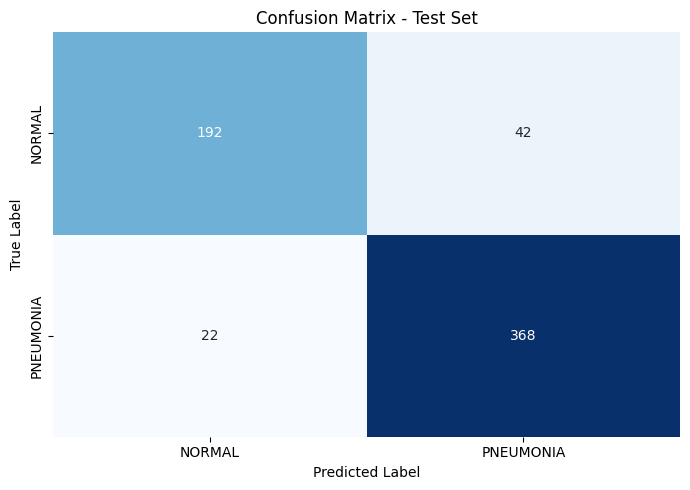

In [17]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report


test_data.reset()
y_prob = model.predict(test_data, verbose=1)


y_pred = (y_prob > 0.5).astype(int).reshape(-1)

# Confusion matrix
cm = confusion_matrix(test_data.classes, y_pred)

# Classification report
class_names = [name for name, index in test_data.class_indices.items()]
print("Classification Report:\n")
print(classification_report(test_data.classes, y_pred, target_names=class_names, digits=4))


tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) != 0 else 0
specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

print("\nConfusion Matrix Values:")
print(f"TN (Normal predicted as Normal):     {tn}")
print(f"FP (Normal predicted as Pneumonia):   {fp}")
print(f"FN (Pneumonia predicted as Normal):   {fn}")
print(f"TP (Pneumonia predicted as Pneumonia): {tp}")

print("\nAdditional Metrics:")
print(f"Sensitivity / Recall: {sensitivity:.4f}")
print(f"Specificity:          {specificity:.4f}")


plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

#**Plot learning curves**

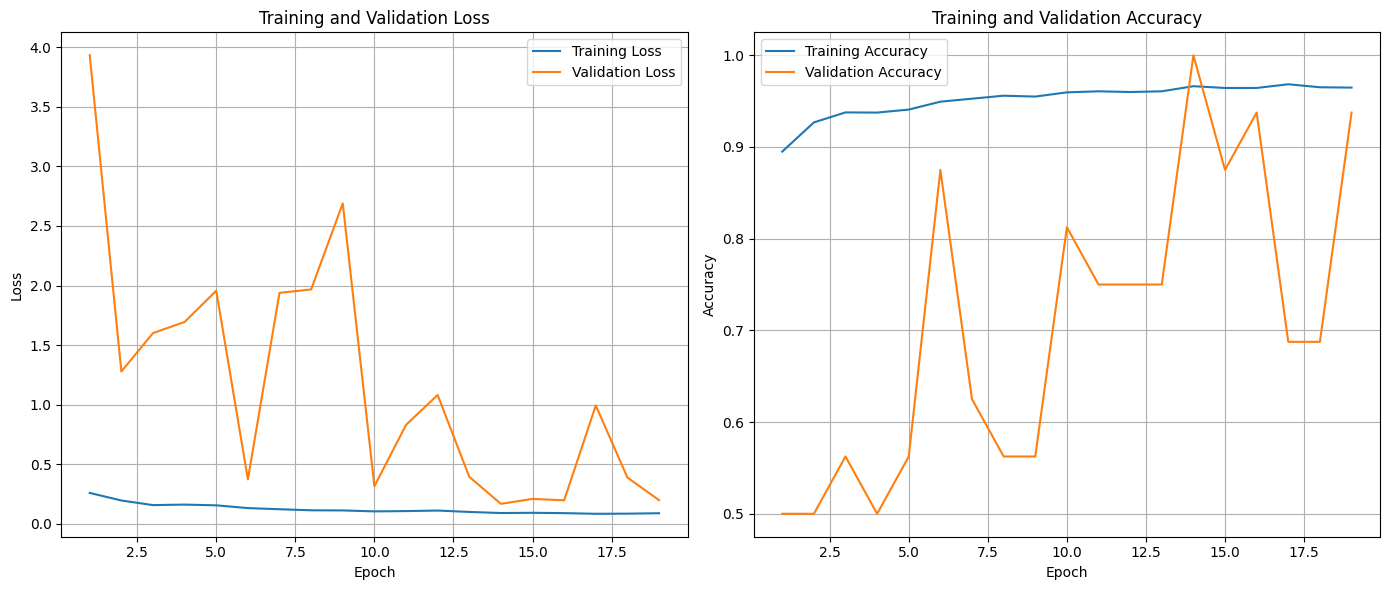

In [19]:
import matplotlib.pyplot as plt

hist = train_log

loss = hist.history.get("loss", [])
val_loss = hist.history.get("val_loss", [])
acc = hist.history.get("accuracy", hist.history.get("acc", []))
val_acc = hist.history.get("val_accuracy", hist.history.get("val_acc", []))

epochs = range(1, len(loss) + 1)

plt.figure(figsize=(14, 6))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()